Imported packages relevant to the model, used pandas to load the dataset from the csv file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Marine_Microplastics.csv')
df.head()

,OBJECTID,Oceans,Regions,SubRegions,Sampling Method,Measurement,Unit,Density Range,Density Class,Short Reference,...,Organization,Keywords,Accession Number,Accession Link,Latitude,Longitude,Date,GlobalID,x,y
0,9676,Atlantic Ocean,NaN,NaN,Grab sample,0.018,pieces/m3,0.005-1,Medium,Barrows et al.2018,...,Adventure Scientist,Adventure Scientist/Citizen Science,211009,https://www.ncei.noaa.gov/access/metadata/land...,-31.696000,-48.560000,08/11/2015 00:00,a77121b2-e113-444e-82d9-7af11d62fdd2,-48.560000,-31.696000
1,6427,Pacific Ocean,NaN,NaN,Neuston net,0.000,pieces/m3,0-0.0005,Very Low,Law et al.2014,...,Sea Education Association,SEA,211008,https://www.ncei.noaa.gov/access/metadata/land...,6.350000,-121.850000,12/18/2002 12:00:00 AM,be27c450-02ca-4261-8d89-cae21108e6cc,-121.850000,6.350000
2,10672,Pacific Ocean,NaN,NaN,Manta net,0.013,pieces/m3,0.005-1,Medium,Goldstein et al.2013,...,Scripps Institution of Oceanography-University...,Great Pacific Garbage Patch/SEAPLEX,253448,https://www.ncei.noaa.gov/access/metadata/land...,0.500000,-95.350000,10/17/2006 12:00:00 AM,23effcdd-35b7-4e1e-adb4-390693a287d3,-95.350000,0.500000
3,13921,Atlantic Ocean,NaN,NaN,Aluminum bucket,1368.000,pieces/m3,>=10,Very High,Queiroz et al.2022,...,"Federal University of Pará, Brazil",Amazon Continental Shelf,276482,https://www.ncei.noaa.gov/access/metadata/land...,0.631825,-45.398158,10/17/2018 12:00:00 AM,16d77822-0533-4116-97b9-0bdb592f3d6e,-45.398158,0.631825
4,9344,Pacific Ocean,NaN,NaN,Grab sample,0.001,pieces/m3,0.0005-0.005,Low,Barrows et al.2018,...,Adventure Scientist,Adventure Scientist/Citizen Science,211009,https://www.ncei.noaa.gov/access/metadata/land...,16.623000,-99.697800,01/03/2015 00:00,b9e435e3-9e86-4143-8b51-877e5dcdc7a6,-99.697800,16.623000


Conducted statistical analysis on dataset.

In [2]:
df.shape
df.columns
df.info()
df.isnull().sum()
df.duplicated().sum()

pd.set_option("display.float_format", "{:.2f}".format)
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20425 entries, 0 to 20424
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OBJECTID          20425 non-null  int64  
 1   Oceans            20154 non-null  str    
 2   Regions           8885 non-null   str    
 3   SubRegions        1307 non-null   str    
 4   Sampling Method   20425 non-null  str    
 5   Measurement       14613 non-null  float64
 6   Unit              20425 non-null  str    
 7   Density Range     20425 non-null  str    
 8   Density Class     20425 non-null  str    
 9   Short Reference   20425 non-null  str    
 10  Long Reference    20425 non-null  str    
 11  DOI               20425 non-null  str    
 12  Organization      20425 non-null  str    
 13  Keywords          20407 non-null  str    
 14  Accession Number  20425 non-null  int64  
 15  Accession Link    20425 non-null  str    
 16  Latitude          20425 non-null  float64
 17  Long

,OBJECTID,Measurement,Accession Number,Latitude,Longitude,x,y
count,20425.00,14613.00,20425.00,20425.00,20425.00,20425.00,20425.00
mean,10864.27,161.98,238756.17,28.22,-81.72,-81.72,28.22
std,6525.77,2198.86,27904.08,14.65,43.02,43.02,14.65
min,1.00,0.00,170967.00,-45.40,-166.54,-166.54,-45.40
25%,5107.00,0.00,211007.00,21.53,-97.22,-97.22,21.53
50%,10668.00,0.01,253450.00,29.08,-81.06,-81.06,29.08
75%,16787.00,0.13,259486.00,34.89,-64.32,-64.32,34.89
max,22338.00,110480.00,285700.00,88.96,40.25,40.25,88.96


Created countplots for Oceans and Sampling Method

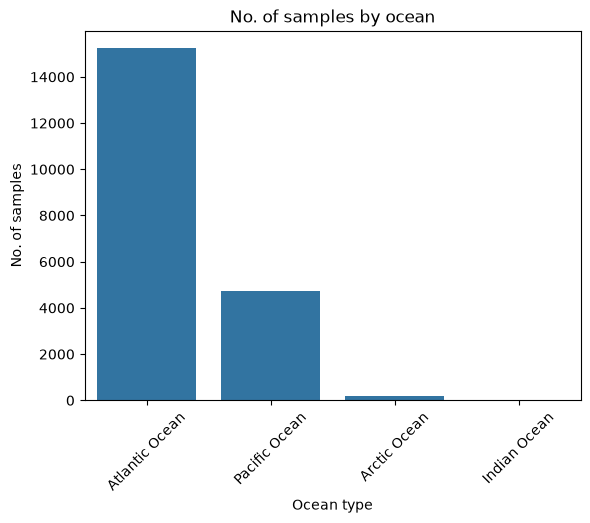

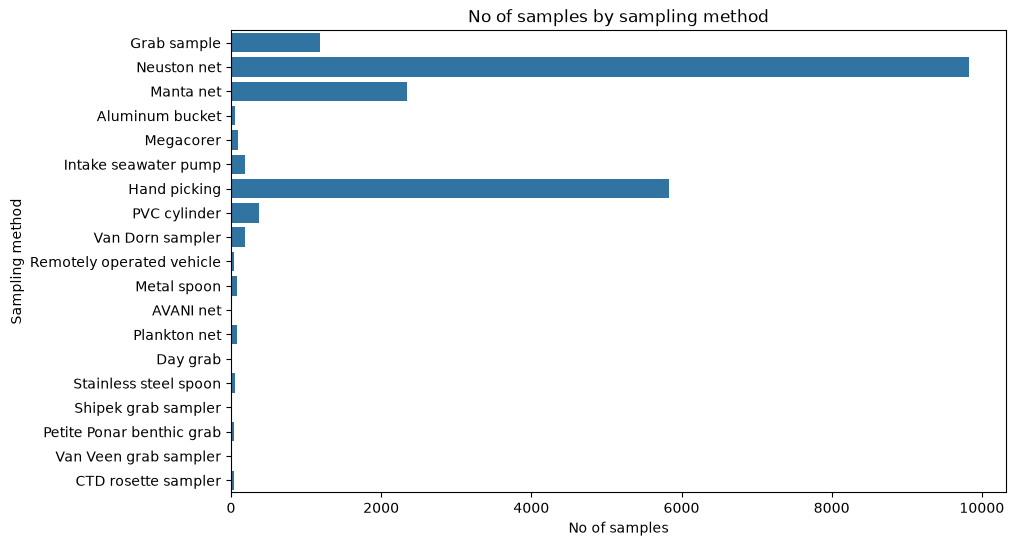

In [3]:
pd.set_option("display.float_format", "{:.2f}".format)
df.describe()

df["Oceans"].value_counts()
sns.countplot(data=df, x="Oceans")

plt.title("No. of samples by ocean")
plt.xlabel("Ocean type")
plt.ylabel("No. of samples")
plt.xticks(rotation=45)

plt.show()


df["Sampling Method"].value_counts()
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="Sampling Method"
)

plt.title("No of samples by sampling method")
plt.xlabel("No of samples")
plt.ylabel("Sampling method")

plt.show()

In [4]:
#Cleaning

df_clean = df.copy().drop_duplicates()
print("Rows after removing duplicates:", len(df_clean))
df.shape
#there are no duplicates


Rows after removing duplicates: 20425


(20425, 22)

In [5]:
#Removing the columns we don't want
df_clean = df_clean.drop(columns=["Density Range", "Long Reference", "DOI", "Short Reference", "Organization", "Keywords", "Accession Number", "Accession Link", "GlobalID", "x", "y"])


In [6]:
df_clean.head()

,OBJECTID,Oceans,Regions,SubRegions,Sampling Method,Measurement,Unit,Density Class,Latitude,Longitude,Date
0,9676,Atlantic Ocean,NaN,NaN,Grab sample,0.02,pieces/m3,Medium,-31.70,-48.56,08/11/2015 00:00
1,6427,Pacific Ocean,NaN,NaN,Neuston net,0.00,pieces/m3,Very Low,6.35,-121.85,12/18/2002 12:00:00 AM
2,10672,Pacific Ocean,NaN,NaN,Manta net,0.01,pieces/m3,Medium,0.50,-95.35,10/17/2006 12:00:00 AM
3,13921,Atlantic Ocean,NaN,NaN,Aluminum bucket,1368.00,pieces/m3,Very High,0.63,-45.40,10/17/2018 12:00:00 AM
4,9344,Pacific Ocean,NaN,NaN,Grab sample,0.00,pieces/m3,Low,16.62,-99.70,01/03/2015 00:00


In [7]:
df_clean.isna().sum()

OBJECTID               0
Oceans               271
Regions            11540
SubRegions         19118
Sampling Method        0
Measurement         5812
Unit                   0
Density Class          0
Latitude               0
Longitude              0
Date                   0
dtype: int64

In [9]:
#To attribute an ocean for the missing values : using nearest neighbors

known = df_clean[df_clean["Oceans"].notna()]
missing = df_clean[df_clean["Oceans"].isna()]

for i, row in missing.iterrows():

    distances = ( (known["Latitude"] - row["Latitude"]) ** 2 + (known["Longitude"] - row["Longitude"]) ** 2 ) #calculating the distance between each know points and the one we are looking for

    nearest_index = distances.idxmin() #choosing the index with the lowest score in distance

    df_clean.loc[i, "Oceans"] = known.loc[nearest_index, "Oceans"] #affecting the ocean to the database


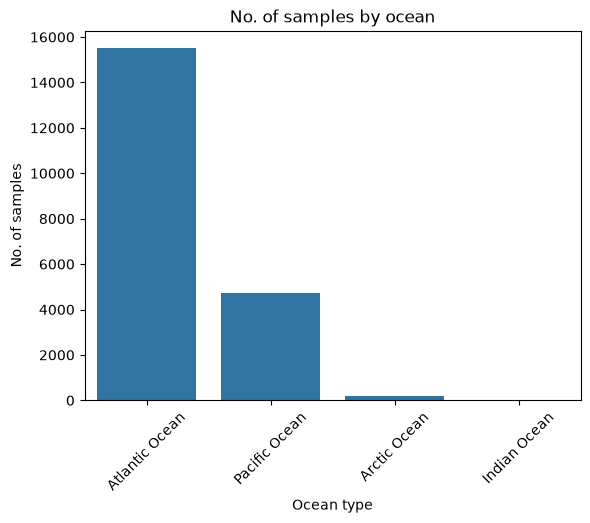

In [17]:
#No. of samples by ocean 

pd.set_option("display.float_format", "{:.2f}".format)
df.describe()

df["Oceans"].value_counts()
sns.countplot(data=df_clean, x="Oceans")

plt.title("No. of samples by ocean")
plt.xlabel("Ocean type")
plt.ylabel("No. of samples")
plt.xticks(rotation=45)

plt.show()

In [12]:
#To attribute a region for the missing values : using nearest neighbors

known = df_clean[df_clean["Regions"].notna()]
missing = df_clean[df_clean["Regions"].isna()]

for i, row in missing.iterrows():

    distances = ( (known["Latitude"] - row["Latitude"]) ** 2 + (known["Longitude"] - row["Longitude"]) ** 2 ) 
    
    nearest_index = distances.idxmin()

    df_clean.loc[i, "Regions"] = known.loc[nearest_index, "Regions"]


OBJECTID               0
Oceans                 0
Regions                0
SubRegions         19118
Sampling Method        0
Measurement         5812
Unit                   0
Density Class          0
Latitude               0
Longitude              0
Date                   0
dtype: int64

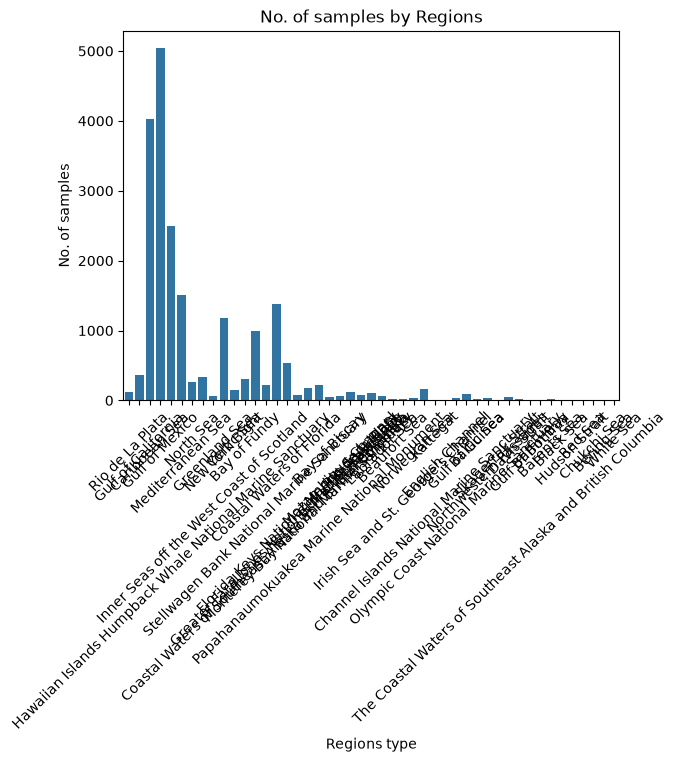

In [18]:
#No. of samples by Regions 

pd.set_option("display.float_format", "{:.2f}".format)
df.describe()

df["Regions"].value_counts()
sns.countplot(data=df_clean, x="Regions")

plt.title("No. of samples by Regions")
plt.xlabel("Regions type")
plt.ylabel("No. of samples")
plt.xticks(rotation=45)

plt.show()

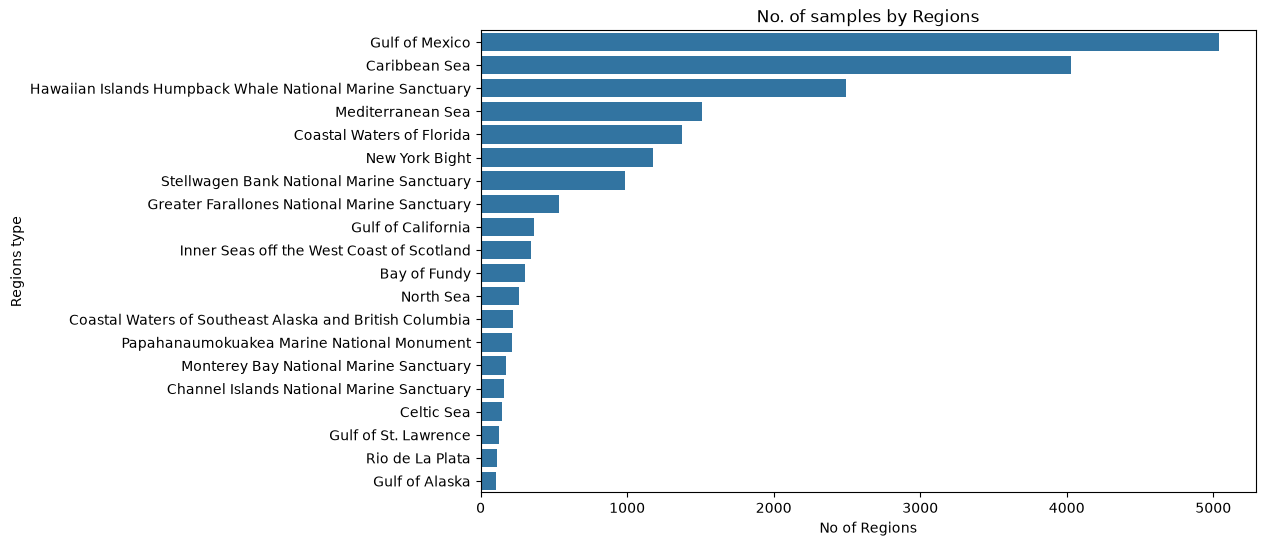

In [27]:
#No. of samples by Regions, but limiting the regions that have at least 100 samples to show up

counts = df_clean["Regions"].value_counts()
counts = counts[counts >= 100]
counts = counts.sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=counts.values,
    y=counts.index
)

plt.title("No. of samples by Regions")
plt.xlabel("No of Regions")
plt.ylabel("Regions type")

plt.show()